In [13]:
import pandas as pd

url = "https://maxi.riken.jp/pubdata/v7.7l/"
tables = pd.read_html(url)
maxi_df = tables[0]

maxi_df = maxi_df.dropna(subset=["Source IDs", "RA", "Dec"]).reset_index(
    drop=True
)
maxi_df["RA"] = pd.to_numeric(maxi_df["RA"], errors="coerce")
maxi_df["Dec"] = pd.to_numeric(maxi_df["Dec"], errors="coerce")

print(maxi_df.head())


   Unnamed: 0                     Source IDs     RA     Dec        L       B  \
0           1                        Mrk 335  1.582  20.203  108.764 -41.424   
1           2                         WW Cet  2.853 -11.479   90.006 -71.743   
2           3                      Tycho SNR  6.308  64.144  120.079   1.418   
3           4  V709 Cas with IGR J00291+5934  7.204  59.289  120.042  -3.455   
4           5        2MASX J00341665-7905204  8.569 -79.089  303.962 -38.005   

                     Category  
0           ExtraGalactic-AGN  
1  Galactic-Compact-Binary-WD  
2                Galactic-SNR  
3  Galactic-Compact-Binary-WD  
4           ExtraGalactic-AGN  


In [14]:
maxi_df = maxi_df.drop("Unnamed: 0", axis=1)
print(maxi_df.head())

                      Source IDs     RA     Dec        L       B  \
0                        Mrk 335  1.582  20.203  108.764 -41.424   
1                         WW Cet  2.853 -11.479   90.006 -71.743   
2                      Tycho SNR  6.308  64.144  120.079   1.418   
3  V709 Cas with IGR J00291+5934  7.204  59.289  120.042  -3.455   
4        2MASX J00341665-7905204  8.569 -79.089  303.962 -38.005   

                     Category  
0           ExtraGalactic-AGN  
1  Galactic-Compact-Binary-WD  
2                Galactic-SNR  
3  Galactic-Compact-Binary-WD  
4           ExtraGalactic-AGN  


In [15]:
maxi_df.to_csv("maxi_cat.csv", index=False)
print(
    "success!!"
)

success!!


In [16]:
import pandas as pd
maxi_df=pd.read_csv('maxi_cat.csv')

print(maxi_df.head(5))

                      Source IDs     RA     DEC        L       B  \
0                        Mrk 335  1.582  20.203  108.764 -41.424   
1                         WW Cet  2.853 -11.479   90.006 -71.743   
2                      Tycho SNR  6.308  64.144  120.079   1.418   
3  V709 Cas with IGR J00291+5934  7.204  59.289  120.042  -3.455   
4        2MASX J00341665-7905204  8.569 -79.089  303.962 -38.005   

                     Category  
0           ExtraGalactic-AGN  
1  Galactic-Compact-Binary-WD  
2                Galactic-SNR  
3  Galactic-Compact-Binary-WD  
4           ExtraGalactic-AGN  


In [17]:
import pandas as pd
url='https://swift.gsfc.nasa.gov/bat_survey/bs105mon/data/BAT_105m_catalog_07jul2019.txt'
df=pd.read_csv(url,sep="\t")
print(df)

         |             BAT_NAME|     RA|    DEC|    SNR|              COUNTERPART_NAME|                     OTHER_NAME| CTPT_RA|CTPT_DEC|    FLUX| FLUX_LO| FLUX_HI|CONTA|GAMM|GAMM|GAMM|  CHI_SQ_R|REDSHIF|  LUM|ASSOC_STREN|        CL2|                 TYPE
0         |                     |    deg|    deg|   ...                                                                                                                                                                                                        
1        1|   SWIFT J0001.0-0708|  0.228| -7.164|   ...                                                                                                                                                                                                        
2        2|   SWIFT J0001.6-7701|  0.445|-77.000|   ...                                                                                                                                                                                 

In [28]:
import pandas as pd
url='https://swift.gsfc.nasa.gov/bat_survey/bs105mon/data/BAT_105m_catalog_07jul2019.txt'
df=pd.read_csv(url,sep="\t")
df_bat = pd.read_csv(url, sep="|")

df_bat.columns = df_bat.columns.str.strip()
df_bat = df_bat.drop(columns=[0], errors="ignore")

df_bat.to_csv("swift_cat.csv", index=False)
print(df_bat.head(5))


                      BAT_NAME       RA      DEC      SNR  \
0                                   deg      deg            
1     1     SWIFT J0001.0-0708    0.228   -7.164     7.73   
2     2     SWIFT J0001.6-7701    0.445  -77.000     6.32   
3     3     SWIFT J0002.5+0323    0.613    3.365     5.50   
4     4     SWIFT J0003.3+2737    0.856   27.643     5.98   

                 COUNTERPART_NAME                       OTHER_NAME   CTPT_RA  \
0                                                                        deg   
1         2MASX J00004876-0709117                                     0.2032   
2                    Fairall 1203                                     0.4419   
3                        NGC 7811                                     0.6103   
4         2MASX J00032742+2739173                                     0.8643   

   CTPT_DEC      FLUX  ...  CONTA  GAMM GAMM.1 GAMM.2    CHI_SQ_R  REDSHIF  \
0       deg  10^-12er  ...                                                

In [27]:
import pandas as pd
df_bat=pd.read_csv('swift_cat.csv')

print(df_bat.head(5))

                BAT_NAME     RA     DEC   SNR                COUNTERPART_NAME  \
0     SWIFT J0001.0-0708  0.228  -7.164  7.73         2MASX J00004876-0709117   
1     SWIFT J0001.6-7701  0.445 -77.000  6.32                    Fairall 1203   
2     SWIFT J0002.5+0323  0.613   3.365  5.50                        NGC 7811   
3     SWIFT J0003.3+2737  0.856  27.643  5.98         2MASX J00032742+2739173   
4     SWIFT J0005.0+7021  0.934  70.358  8.52         2MASX J00040192+7019185   

                        OTHER_NAME  CTPT_RA  CTPT_DEC   FLUX  FLUX_LO  ...  \
0                                    0.2032   -7.1532  13.49    11.10  ...   
1                                    0.4419  -76.9540  13.23    10.47  ...   
2                                    0.6103    3.3519  10.79     7.89  ...   
3                                    0.8643   27.6548  10.29     7.75  ...   
4                                    1.0082   70.3217  13.41    11.09  ...   

   CONTA  GAMM  GAMM.1  GAMM.2  CHI_SQ_R  RE

In [31]:
import pandas as pd
import numpy as np

maxi = pd.read_csv("maxi_cat.csv")
swift = pd.read_csv("swift_cat.csv")

radius = 5 / 60  # degrees

swift_ra = np.radians(swift['RA'].values)  #precompute swift coord
swift_dec = np.radians(swift['DEC'].values)

matches = []


for i in range(len(maxi)):

    ra1 = np.radians(maxi.loc[i, 'RA'])
    dec1 = np.radians(maxi.loc[i, 'DEC'])

    cos_theta = (                                       #angular sep
        np.sin(dec1) * np.sin(swift_dec)
        + np.cos(dec1) * np.cos(swift_dec)
        * np.cos(ra1 - swift_ra)
    )

    cos_theta = np.clip(cos_theta, -1, 1)

    sep_deg = np.degrees(np.arccos(cos_theta))

    idx = np.where(sep_deg <= radius)[0]

    for j in idx:
        matches.append({
            'MAXI_source': maxi.loc[i, 'Source IDs'],   # <-- change if column name differs
            'MAXI_RA': maxi.loc[i, 'RA'],
            'MAXI_DEC': maxi.loc[i, 'DEC'],

            'Swift_source': swift.loc[j, 'BAT_NAME'],
            'Swift_RA': swift.loc[j, 'RA'],
            'Swift_DEC': swift.loc[j, 'DEC'],

            'Separation_arcmin': sep_deg[j] * 60
        })
result = pd.DataFrame(matches)

print(result)

result.to_csv("MAXI_Swift_crossmatch.csv", index=False)

print("\nTotal matches:", len(result))

                            MAXI_source  MAXI_RA  MAXI_DEC  \
0                               Mrk 335    1.582    20.203   
1                             Tycho SNR    6.308    64.144   
2         V709 Cas with IGR J00291+5934    7.204    59.289   
3               2MASX J00341665-7905204    8.569   -79.089   
4    1ES 0033+595, 87GB 003300.9+593328    8.969    59.835   
..                                  ...      ...       ...   
256                             Mrk 926  346.181    -8.686   
257                            NGC 7603  349.736     0.244   
258                            NGC 7582  349.598   -42.371   
259              Cas A, SNR G111.7-02.1  350.850    58.815   
260                       QSO B2356-309  359.783   -30.628   

              Swift_source  Swift_RA  Swift_DEC  Separation_arcmin  
0       SWIFT J0006.2+2012     1.596     20.242           2.469188  
1       SWIFT J0025.2+6410     6.326     64.142           0.486062  
2       SWIFT J0028.9+5917     7.162     59.266 

In [36]:
print(maxi.columns)
print(swift.columns)

Index(['Source IDs', 'RA', 'DEC', 'L', 'B', 'Category'], dtype='object')
Index(['BAT_NAME', 'RA', 'DEC', 'SNR', 'COUNTERPART_NAME', 'OTHER_NAME',
       'CTPT_RA', 'CTPT_DEC', 'FLUX', 'FLUX_LO', 'FLUX_HI', 'CONTA', 'GAMM',
       'GAMM.1', 'GAMM.2', 'CHI_SQ_R', 'REDSHIF', 'LUM', 'ASSOC_STREN', 'CL2',
       'TYPE'],
      dtype='object')


In [1]:
import pandas as pd
import numpy as np
import time

from astropy.coordinates import SkyCoord
import astropy.units as u
from alerce.core import Alerce

client = Alerce()

maxi = pd.read_csv("maxi_cat.csv")
swift = pd.read_csv("swift_cat.csv")

maxi.columns = maxi.columns.str.strip()
swift.columns = swift.columns.str.strip()


swift["CTPT_RA"] = pd.to_numeric(swift["CTPT_RA"], errors="coerce")
swift["CTPT_DEC"] = pd.to_numeric(swift["CTPT_DEC"], errors="coerce")

swift = swift.dropna(subset=["CTPT_RA", "CTPT_DEC"]).reset_index(drop=True)


maxi_coord = SkyCoord(maxi["RA"].astype(float),
                      maxi["DEC"].astype(float),
                      unit=u.deg)

swift_coord = SkyCoord(swift["CTPT_RA"].astype(float),
                       swift["CTPT_DEC"].astype(float),
                       unit=u.deg)

# maxi to swift crossmatch
radius_ms = 3 * u.arcmin

idx_swift, idx_maxi, sep_ms, _ = maxi_coord.search_around_sky(
    swift_coord,
    radius_ms
)

print("MAXI objects:", len(maxi))
print("Swift objects:", len(swift))
print("MAXI–Swift matches:", len(idx_swift))

#swift to ztf
radius_ztf = 5  # arcsec

results = []

for k in range(len(idx_swift)):

    sw_i = idx_swift[k]
    mx_i = idx_maxi[k]
    sep = sep_ms[k]

    ra = float(swift.loc[sw_i, "CTPT_RA"])
    dec = float(swift.loc[sw_i, "CTPT_DEC"])

    try:
        ztf_match = client.query_objects(
            ra=ra,
            dec=dec,
            radius=radius_ztf,
            format="pandas"
        )

        if ztf_match is None or ztf_match.empty:
            continue

        best = ztf_match.iloc[0]

        results.append({
            "MAXI_source": maxi.loc[mx_i, "Source IDs"],
            "MAXI_RA": maxi.loc[mx_i, "RA"],
            "MAXI_DEC": maxi.loc[mx_i, "DEC"],

            "Swift_source": swift.loc[sw_i, "BAT_NAME"],
            "Swift_RA": ra,
            "Swift_DEC": dec,

            "ZTF_oid": best.get("oid"),
            "ZTF_class": best.get("class"),

            "n_ztf_matches": len(ztf_match),

            
            "MAXI_SWIFT_sep_arcsec": sep.to(u.arcsec).value
        })

    except Exception as e:
        print(f"ERROR at {k}: {repr(e)}")

    time.sleep(0.2)


final_df = pd.DataFrame(results)

print("\n================ FINAL CATALOG ================")
print(final_df)

final_df.to_csv("MAXI_SWIFT_ZTF_catalog_fixed.csv", index=False)

print("\nTOTAL MATCHED SYSTEMS:", len(final_df))

MAXI objects: 433
Swift objects: 1632
MAXI–Swift matches: 262

================ FINAL CATALOG ================
                            MAXI_source  MAXI_RA  MAXI_DEC  \
0                               Mrk 335    1.582    20.203   
1    1ES 0033+595, 87GB 003300.9+593328    8.969    59.835   
2                               Mrk 348   12.196    31.957   
3                              Mrk 1148   12.978    17.433   
4   1ES 0120+340, SHBL J012308.7+342049   20.786    34.347   
..                                  ...      ...       ...   
78                      IGR J06074+2205   91.861    22.097   
79            S5 0716+71, HB89 0716+714  110.473    71.343   
80                             NGC 2617  128.912    -4.088   
81                                 M 51  202.470    47.195   
82   MAXI J1910-057, Swift J1910.2-0546  287.595    -5.799   

             Swift_source  Swift_RA  Swift_DEC       ZTF_oid ZTF_class  \
0      SWIFT J0006.2+2012    1.5813    20.2029  ZTF18abwfdbb      None

**Sources for SAX J1808.4−3658 in ztf**

In [1]:
from alerce.core import Alerce
client = Alerce()

In [2]:
saxj1808 = client.query_objects(
    survey="ztf",
    ra=272.115083,
    dec=-36.978889,
    radius=30
)

print(saxj1808)

Empty DataFrame
Columns: []
Index: []


**Swift J1727.8-1613**

In [5]:
saxj1727 = client.query_objects(
    survey="ztf",
    ra=261.930500,
    dec=-16.205167,
    radius=10
)

print(saxj1727)

            oid ndethist  ncovhist  mjdstarthist    mjdendhist  corrected  \
0  ZTF23abaewkl       36      1408  60184.168704  60451.416597       True   

   stellar  ndet   g_r_max g_r_max_corr  ...       lastmjd     deltajd  \
0    False    39 -0.044144         None  ...  60451.416597  267.247894   

       meanra    meandec  sigmara  sigmadec  class  classifier  probability  \
0  261.930468 -16.205319  0.01819  0.017467   None        None         None   

  step_id_corr  
0       24.4.1  

[1 rows x 23 columns]


In [6]:
lc = client.query_lightcurve("ZTF23abaewkl", survey="ztf")

lc

{'detections': [{'tid': 'ztf',
   'mjd': 60184.16870369995,
   'candid': '2430168704315015003',
   'fid': 2,
   'pid': 2430168704315,
   'diffmaglim': 19.380753,
   'isdiffpos': 1,
   'nid': 2430,
   'distnr': 0.08878495,
   'magpsf': 12.840439,
   'magpsf_corr': 12.837976,
   'magpsf_corr_ext': None,
   'magap': 12.8478,
   'magap_corr': None,
   'sigmapsf': 0.025839971,
   'sigmapsf_corr': 0.025781093,
   'sigmapsf_corr_ext': 0.025781427,
   'sigmagap': 0.0015,
   'sigmagap_corr': None,
   'ra': 261.9304746,
   'dec': -16.2053189,
   'rb': 0.7114286,
   'rbversion': 't17_f5_c3',
   'drb': 0.9997023,
   'magapbig': 12.8414,
   'sigmagapbig': 0.0017,
   'rfid': 331120243,
   'has_stamp': True,
   'corrected': True,
   'dubious': False,
   'candid_alert': None,
   'step_id_corr': '1.2.0',
   'phase': 0.0,
   'parent_candid': None},
  {'tid': 'ztf',
   'mjd': 60184.1903241002,
   'candid': '2430190324315015005',
   'fid': 1,
   'pid': 2430190324315,
   'diffmaglim': 18.970585,
   'isdiff

In [11]:
detections_df = pd.DataFrame(lc['detections'])
display(detections_df.head())

,tid,mjd,candid,fid,pid,diffmaglim,isdiffpos,nid,distnr,magpsf,...,magapbig,sigmagapbig,rfid,has_stamp,corrected,dubious,candid_alert,step_id_corr,phase,parent_candid
0,ztf,60184.168704,2430168704315015003,2,2430168704315,19.380753,1,2430,0.088785,12.840439,...,12.8414,0.0017,331120243.0,True,True,False,None,1.2.0,0.0,NaN
1,ztf,60184.190324,2430190324315015005,1,2430190324315,18.970585,1,2430,2.008040,12.796295,...,12.7718,0.0018,331120143.0,True,False,False,None,1.2.0,0.0,NaN
2,ztf,60186.204745,2432204744315015000,1,2432204744315,18.936270,1,2432,2.002316,12.967569,...,12.9553,0.0022,331120143.0,True,False,False,None,1.2.0,0.0,NaN
3,ztf,60186.212292,2432212294315015003,2,2432212294315,19.232920,1,2432,0.122914,12.906101,...,12.9143,0.0020,331120243.0,True,True,False,None,1.2.0,0.0,NaN
4,ztf,60188.158125,2434158124315015002,1,2434158124315,19.404781,1,2434,2.047013,12.886397,...,12.8674,0.0018,331120143.0,True,False,False,None,1.2.0,0.0,NaN


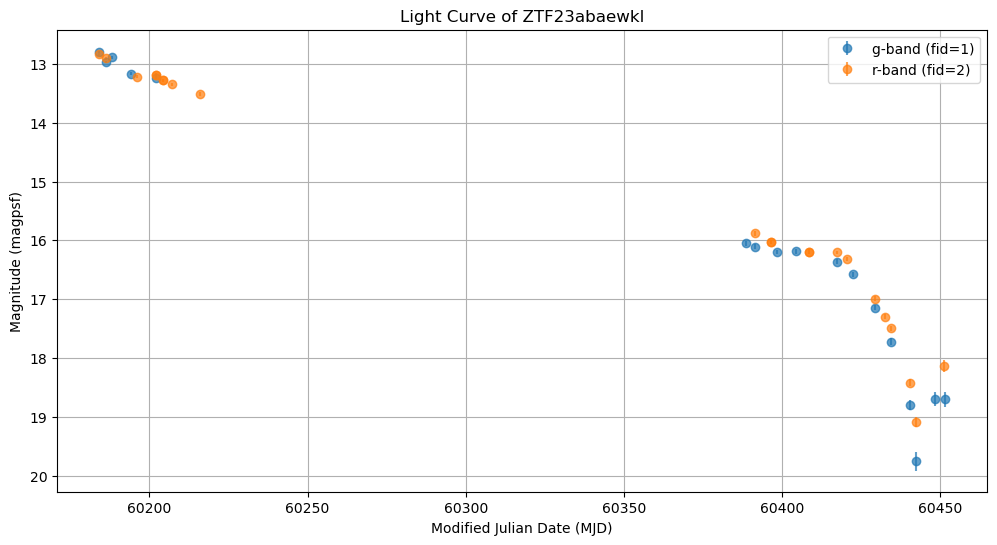

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Filter for g-band (fid=1)
g_band = detections_df[detections_df['fid'] == 1]
ax.errorbar(g_band['mjd'], g_band['magpsf'], yerr=g_band['sigmapsf'], fmt='o', label='g-band (fid=1)', alpha=0.7)

# Filter for r-band (fid=2)
r_band = detections_df[detections_df['fid'] == 2]
ax.errorbar(r_band['mjd'], r_band['magpsf'], yerr=r_band['sigmapsf'], fmt='o', label='r-band (fid=2)', alpha=0.7)

ax.set_xlabel('Modified Julian Date (MJD)')
ax.set_ylabel('Magnitude (magpsf)')
ax.set_title('Light Curve of ZTF23abaewkl')
ax.invert_yaxis() 
ax.legend()
ax.grid(True)
plt.show()